# CNN (Convolutional Neural Network)

CNN is a type of deep learning model that is particularly effective for image recognition and classification tasks. It is designed to automatically and adaptively learn spatial hierarchies of features from input images. CNNs are composed of multiple layers, including convolutional layers, pooling layers, and fully connected layers.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# remove the tf warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [5]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
# Normalize the pixel values to the range [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape the data to fit the model
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28, 1), (60000,), (10000, 28, 28, 1), (10000,))

In [8]:
# Build a simple CNN model
# the building block will be Conv2D -> MaxPooling2D
# so the architecture will be Block -> Block -> Flatten -> Dense
model_cnn = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [9]:
model_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Let's break down the input and output of each layer in the model:

Input Layer: $(28, 28, 1)$
The first layer is a conv2d layers with 32 filters, kernel size of (3, 3) and conv type of 'valid' (default).

Formula for output shape of conv2d layer:
$$
\text{Output} = \left\lfloor \frac{\text{Input} - \text{Kernel} + 2 \times \text{Padding}}{\text{Stride}} \right\rfloor + 1
$$

Where :

- Input is the height or width of the input image (28 in this case)
- Kernel is the height or width of the kernel (3 in this case)
- Padding is the number of pixels added to the input image (0 in this case, 1 if padding is 'same')
- Stride is the number of pixels the kernel moves across the input image (1 in this case)

Number of parameters in conv2d layer:

$$
\text{Number of Parameters} = (\text{Kernel Height} \times \text{Kernel Width} \times \text{Input Channels} + 1) \times \text{Number of Filters}
$$

Let's plug in the values:

$$
\text{Output Height} = \left\lfloor \frac{28 - 3 + 0}{1} \right\rfloor + 1 = 26
$$

SO we get output shape of $(26, 26, 32)$

Let's calculate the number of parameters in the first conv2d layer:

$$
\text{Number of Parameters} = (3 \times 3 \times 1 + 1) \times 32 = 320
$$

Next, we have a MaxPooling2D layer with pool size of (2, 2).

Formula for output shape of max pooling layer:

$$
\text{Output} = \left\lfloor \frac{\text{Input} - \text{Pool Size}}{\text{Stride}} \right\rfloor + 1
$$

Let's plug in the values:

$$
\text{Output Height} = \left\lfloor \frac{26 - 2}{2} \right\rfloor + 1 = 13
$$

So we get output shape of $(13, 13, 32)$

In [12]:
# compile the mode
model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [13]:
# let's do a long training without early stopping to see how the model performs
history = model_cnn.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=30,
    batch_size=32,
    verbose=2,
    shuffle=True,
    callbacks=[]
)

Epoch 1/30
1875/1875 - 12s - 7ms/step - accuracy: 0.9752 - loss: 0.2461 - val_accuracy: 0.9815 - val_loss: 0.2457
Epoch 2/30
1875/1875 - 12s - 6ms/step - accuracy: 0.9697 - loss: 0.8780 - val_accuracy: 0.9775 - val_loss: 1.1235
Epoch 3/30
1875/1875 - 13s - 7ms/step - accuracy: 0.9699 - loss: 2.2743 - val_accuracy: 0.9749 - val_loss: 2.4727
Epoch 4/30
1875/1875 - 12s - 6ms/step - accuracy: 0.9715 - loss: 3.9821 - val_accuracy: 0.9699 - val_loss: 5.3357
Epoch 5/30
1875/1875 - 12s - 6ms/step - accuracy: 0.9704 - loss: 7.8336 - val_accuracy: 0.9753 - val_loss: 7.8658
Epoch 6/30
1875/1875 - 13s - 7ms/step - accuracy: 0.9706 - loss: 11.9241 - val_accuracy: 0.9663 - val_loss: 16.7836
Epoch 7/30
1875/1875 - 11s - 6ms/step - accuracy: 0.9691 - loss: 21.2760 - val_accuracy: 0.9764 - val_loss: 20.9779
Epoch 8/30
1875/1875 - 13s - 7ms/step - accuracy: 0.9703 - loss: 30.0235 - val_accuracy: 0.9745 - val_loss: 31.3111
Epoch 9/30
1875/1875 - 11s - 6ms/step - accuracy: 0.9693 - loss: 44.2485 - val_acc

In [14]:
def plot_training_history(history):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

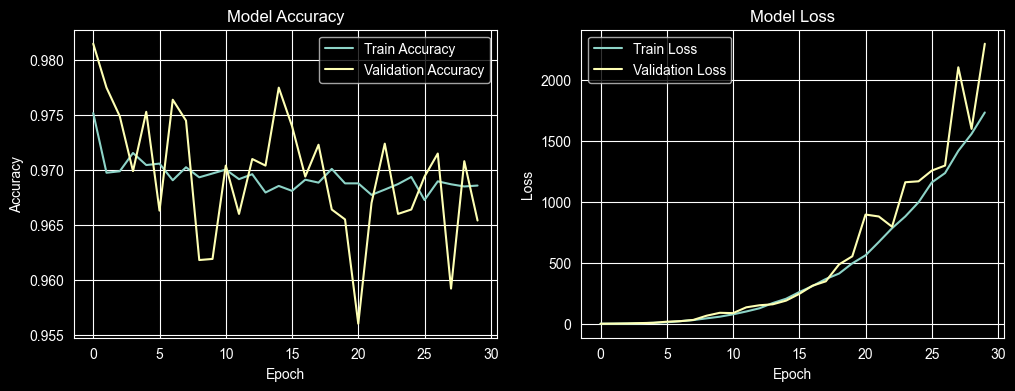

In [15]:
plot_training_history(history)

As we can see from the graphs, the model loss goes up through the epochs, for both the training and validation, and the training accuracy for is quite stable but the validation accuracy is quite unstable, it goes up and down, which is a sign of overfitting, so we can use early stopping to prevent overfitting and get a better performance on the test set.

In [17]:
# let's retrain the model with early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [21]:
# let's wipe out the memory of the model and start from the beginning
model_cnn = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [22]:
# compile the model again
model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

In [23]:
history = model_cnn.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=30,
    batch_size=32,
    verbose=2,
    shuffle=True,
    callbacks=[early_stopping]
)

Epoch 1/30
1875/1875 - 13s - 7ms/step - accuracy: 0.9525 - loss: 0.1545 - val_accuracy: 0.9802 - val_loss: 0.0660
Epoch 2/30
1875/1875 - 11s - 6ms/step - accuracy: 0.9797 - loss: 0.0698 - val_accuracy: 0.9870 - val_loss: 0.0481
Epoch 3/30
1875/1875 - 12s - 6ms/step - accuracy: 0.9811 - loss: 0.0782 - val_accuracy: 0.9862 - val_loss: 0.0572
Epoch 4/30
1875/1875 - 14s - 7ms/step - accuracy: 0.9798 - loss: 0.1388 - val_accuracy: 0.9841 - val_loss: 0.1406
Epoch 5/30
1875/1875 - 12s - 6ms/step - accuracy: 0.9797 - loss: 0.2718 - val_accuracy: 0.9808 - val_loss: 0.3388


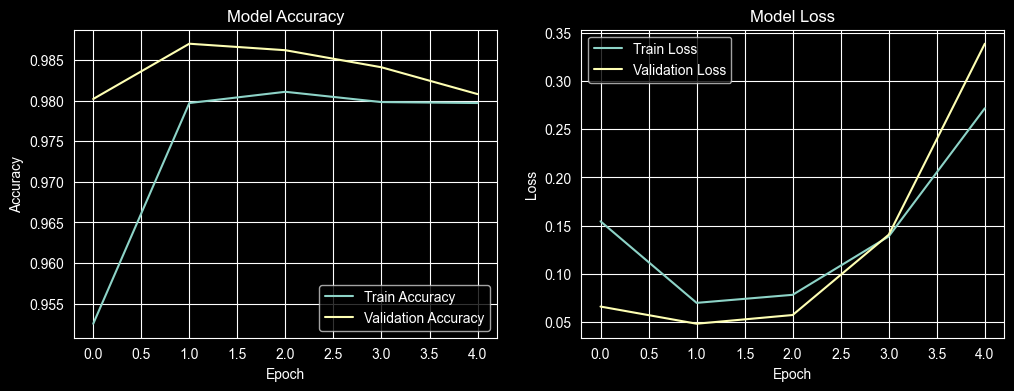

In [24]:
plot_training_history(history)

In [25]:
# evaluate the model on the test set
test_loss, test_accuracy = model_cnn.evaluate(x_test, y_test, verbose=0)
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')

Test Loss: 0.0481, Test Accuracy: 0.9870


Let's try adding a batch normalization layer after each conv2d layer to see if it helps with the training and performance of the model.

In [26]:
model_cnn2 = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [27]:
model_cnn2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,314 (477.79 KB)

 Trainable params: 122,122 (477.04 KB)

 Non-trainable params: 192 (768.00 B)

The batch normalization layer has parameters here is the formula to calculate the number of parameters in a batch normalization layer:

$$
\text{Number of Parameters} = 2 \times \text{Number of Features} + 2 \times \text{Number of Features}
$$

There are 2 learned parameters $\gamma$ and $\beta$ for each feature, and 2 non-learned parameters (moving mean $\mathbb{E}[x]=\mu$ and moving variance $\mathbb{V}[x] = \sigma^2$) for each feature, so the total number of parameters is:

$$
\text{Number of Parameters} = 4 \times \text{Number of Features}
$$

The normalization is as follows:

$$
\hat{x} = \frac{x - \mu}{\sqrt{\sigma^2 + \varepsilon}} \cdot \gamma + \beta
$$

In our case after the first conv2d layer, we have 32 filters, so the number of features is 32, and the number of parameters in the batch normalization layer will be:

$$
\text{Number of Parameters} = 4 \times 32 = 128
$$

In [28]:
# compile the model
model_cnn2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

In [29]:
# train the model
history = model_cnn2.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=30,
    batch_size=32,
    verbose=2,
    shuffle=True,
    callbacks=[early_stopping]
)

Epoch 1/30
1875/1875 - 21s - 11ms/step - accuracy: 0.9562 - loss: 0.1747 - val_accuracy: 0.9731 - val_loss: 0.1508
Epoch 2/30
1875/1875 - 19s - 10ms/step - accuracy: 0.9759 - loss: 0.1510 - val_accuracy: 0.9789 - val_loss: 0.1410
Epoch 3/30
1875/1875 - 17s - 9ms/step - accuracy: 0.9803 - loss: 0.1689 - val_accuracy: 0.9811 - val_loss: 0.1685


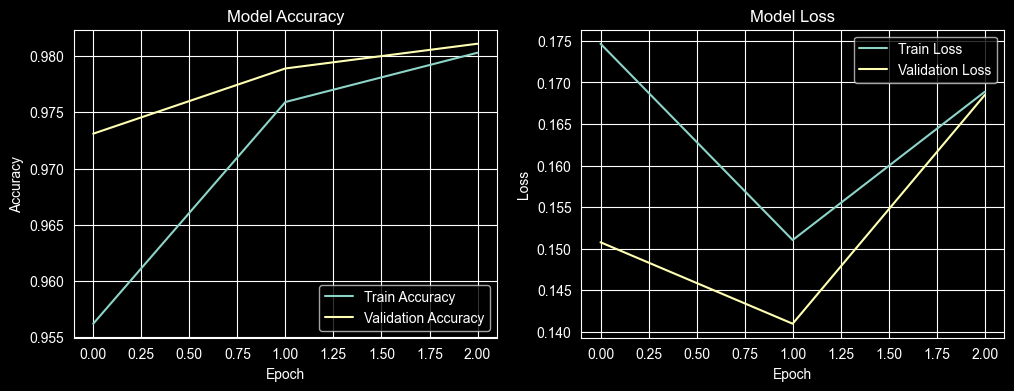

In [30]:
# plot the training history
plot_training_history(history)

In [31]:
# evaluate the model on the test set
test_loss, test_accuracy = model_cnn2.evaluate(x_test, y_test, verbose=0)
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')

Test Loss: 0.1508, Test Accuracy: 0.9731


## Kernel Visualization

Let's try to visualize the kernels of the first conv2d layer to see what kind of features the model is learning.

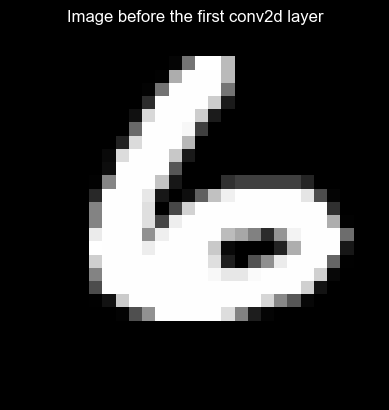

In [42]:
# get an example of image and plot them before the first conv2d layer and after the first conv2d layer
random_idx  = np.random.randint(0, x_test.shape[0])
image = x_test[random_idx]

# plot the image before the first conv2d layer
plt.imshow(image.squeeze(), cmap='gray')
plt.title('Image before the first conv2d layer')
plt.axis('off')
plt.show()

In [45]:
image.shape

(28, 28, 1)

In [53]:
# pass the image through the first block of conv2d + max pooling

# get the first layer of the model
layer_conv2d = model_cnn.layers[0]

# reshape the image to be (1, 28, 28, 1) to pass it through the model
image = image.reshape(1, 28, 28, 1)

# get the output of the first conv2d layer
image_conv2d = layer_conv2d(image)

In [54]:
image_conv2d.shape

TensorShape([1, 26, 26, 32])

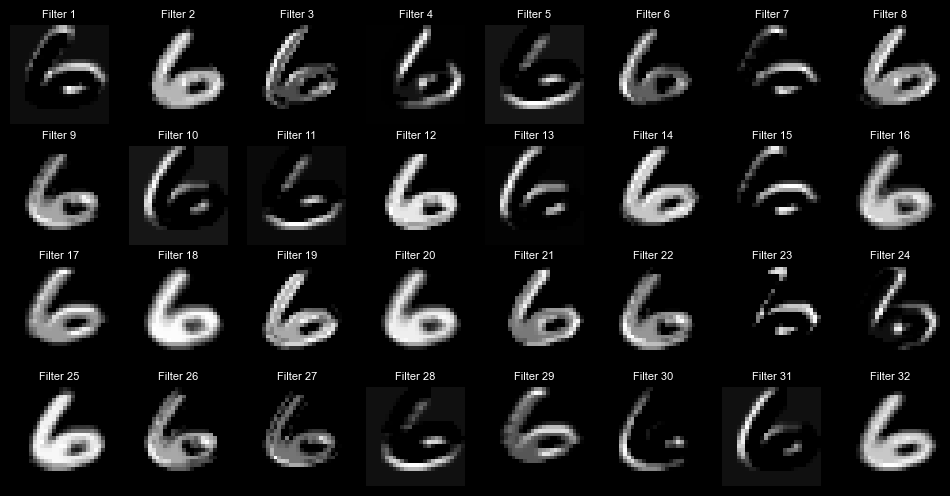

In [63]:
# now we have (1, 26, 26, 32) we want to plot the 32 filters of the first conv2d layer

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
axes = axes.flatten()

for i in range(32):
    axes[i].imshow(image_conv2d[0, :, :, i], cmap='gray')
    axes[i].set_title(f'Filter {i+1}', fontsize=8)
    axes[i].axis('off')
plt.show()

Let's continue further let's now continue to go through the network and see the output after the first max pooling layer.

In [56]:
# now pass the output of the first conv2d layer through the first max pooling layer
max_pool_1 = model_cnn.layers[1]
image_max_pool_1 = max_pool_1(image_conv2d)

image_max_pool_1.shape

TensorShape([1, 13, 13, 32])

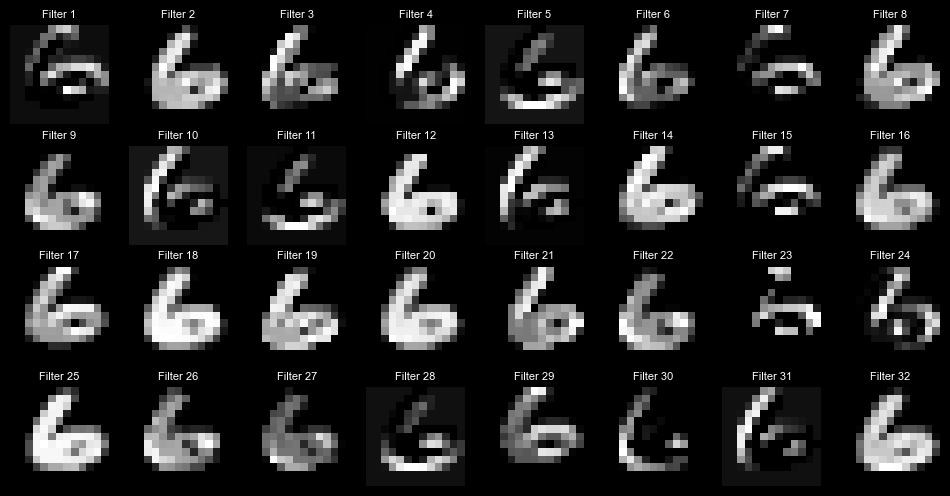

In [64]:
# now we have (1, 13, 13, 32) we want to plot the 32 filters of the first max pooling layer

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
axes = axes.flatten()
for i in range(32):
    axes[i].imshow(image_max_pool_1[0, :, :, i], cmap='gray')
    axes[i].set_title(f'Filter {i+1}', fontsize=8)
    axes[i].axis('off')
plt.show()

In [58]:
# continuing through the network, let's pass the output of the first max pooling layer through the second conv2d layer
layer_conv2d2 = model_cnn.layers[2]

image_conv2d2 = layer_conv2d2(image_max_pool_1)

image_conv2d2.shape

TensorShape([1, 11, 11, 64])

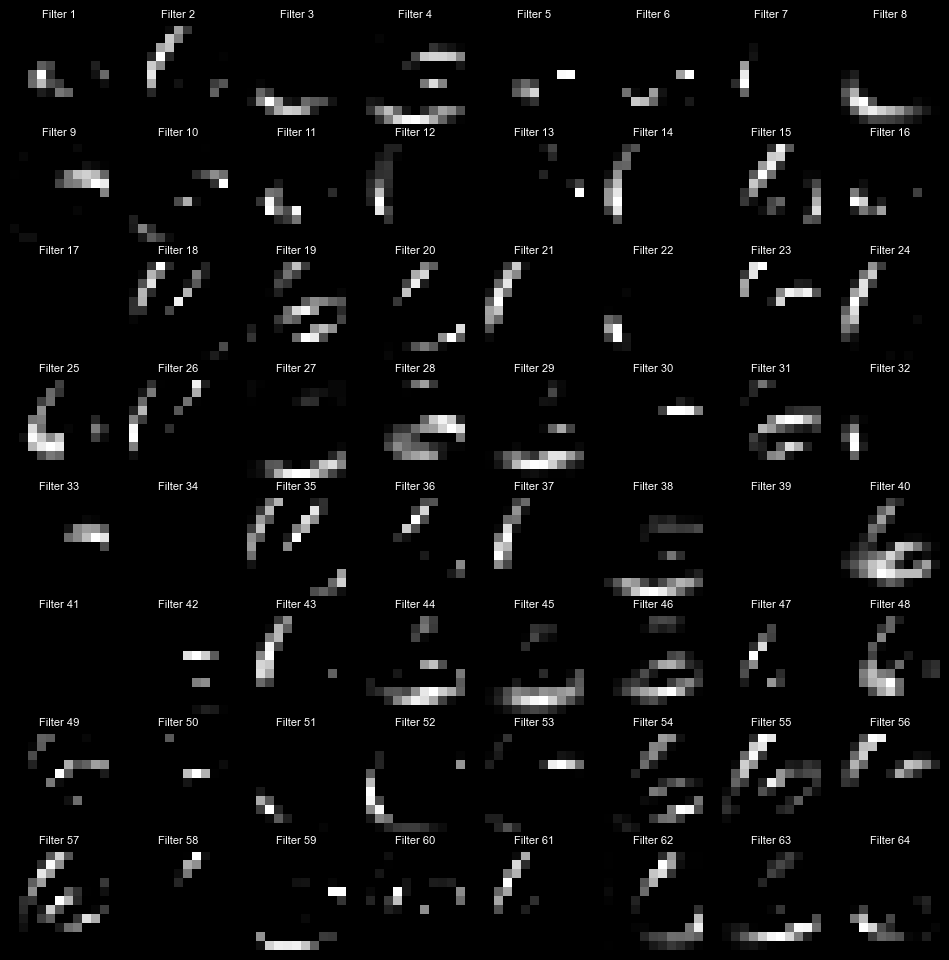

In [65]:
# now we have (1, 11, 11, 64) we want to plot the 64 filters of the second conv2d layer

fig, axes = plt.subplots(8, 8, figsize=(12, 12))
axes = axes.flatten()
for i in range(64):
    axes[i].imshow(image_conv2d2[0, :, :, i], cmap='gray')
    axes[i].set_title(f'Filter {i+1}', fontsize=8)
    axes[i].axis('off')
plt.show()

In [60]:
# let's pass the output of the max pooling layer through the second max pooling layer
max_pool_2 = model_cnn.layers[3]
image_max_pool_2 = max_pool_2(image_conv2d2)
image_max_pool_2.shape

TensorShape([1, 5, 5, 64])

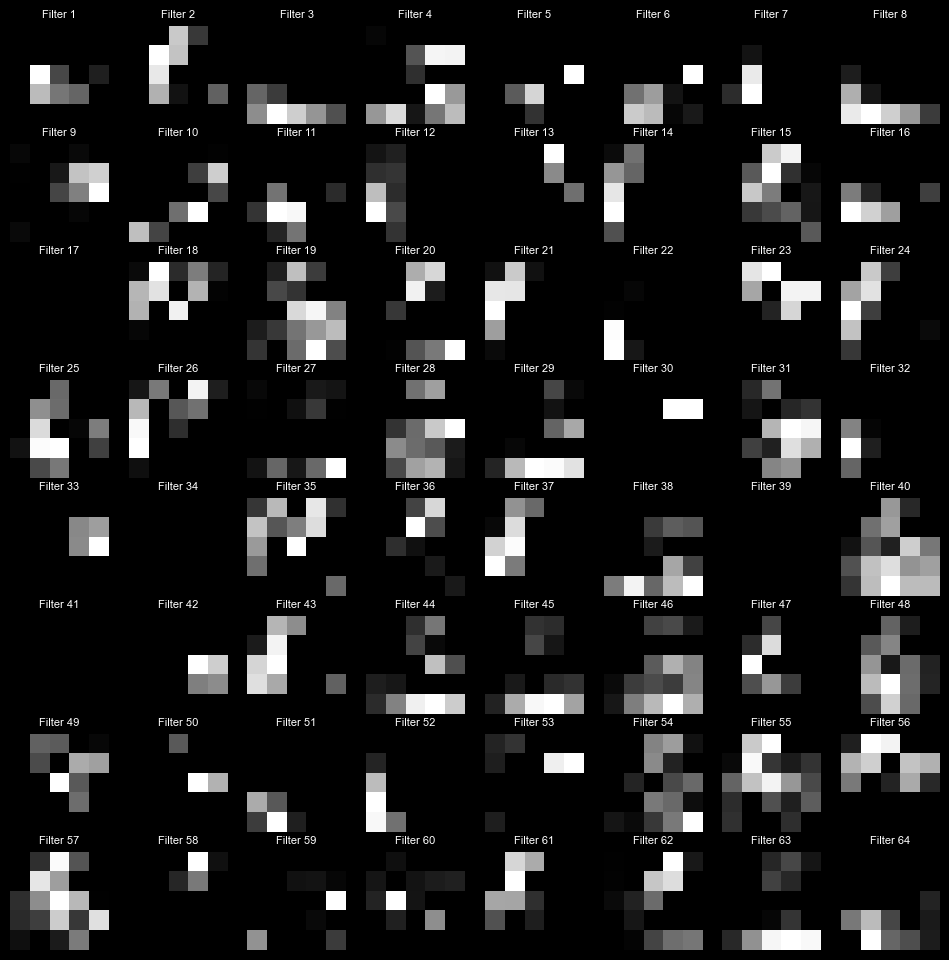

In [62]:
# now we have (1, 5, 5, 64) we want to plot the 64 filters of the second max pooling layer

fig, axes = plt.subplots(8, 8, figsize=(12, 12))
axes = axes.flatten()
for i in range(64):
    axes[i].imshow(image_max_pool_2[0, :, :, i], cmap='gray')
    axes[i].set_title(f'Filter {i+1}', fontsize=8)
    axes[i].axis('off')
plt.show()